In [118]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv


#  **Setup & Imports**

In [119]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import string
from collections import Counter
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
import wandb

sns.set_style("whitegrid")

import warnings
warnings.filterwarnings('ignore')

# **Dataset Description**

##  Load Data

In [120]:
DATA_PATH   = "/kaggle/input/competitions/smart-mcq-solver-challenge"
OPTION_COLS = ["A", "B", "C", "D", "E"]


In [121]:
train = pd.read_csv(os.path.join(DATA_PATH, "train.csv"))
test  = pd.read_csv(os.path.join(DATA_PATH, "test.csv"))

print("Train shape:", train.shape)
print("Test shape :", test.shape)
train.head(5)


Train shape: (2000, 8)
Test shape : (500, 7)


,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C
3,4,Select the most accurate option: What is Marti...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
4,5,Identify the correct statement: What is the co...,"Simultaneity is relative, meaning that two eve...","Simultaneity is relative, meaning that two eve...","Simultaneity is absolute, meaning that two eve...",Simultaneity is a concept that applies only to...,Simultaneity is a concept that applies only to...,A


# **EDA & Preprocessing**

## Basic Info

In [122]:
print("TRAIN INFO:")
print(train.info())


TRAIN INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2000 non-null   int64 
 1   prompt  2000 non-null   object
 2   A       2000 non-null   object
 3   B       2000 non-null   object
 4   C       2000 non-null   object
 5   D       2000 non-null   object
 6   E       2000 non-null   object
 7   answer  2000 non-null   object
dtypes: int64(1), object(7)
memory usage: 125.1+ KB
None


## Missing Values

In [123]:
print("MISSING VALUES")
print(train.isnull().sum())


MISSING VALUES
id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
answer    0
dtype: int64


##  Duplicate Values

In [124]:
print("DUPLICATES:")
print("Duplicate rows in train:", train.duplicated().sum())
print("Duplicate prompts      :", train['prompt'].duplicated().sum())


DUPLICATES:
Duplicate rows in train: 0
Duplicate prompts      : 242


In [125]:
# Duplicate prompts explore
dup_prompts = train[train['prompt'].duplicated(keep=False)].sort_values('prompt')
print(f"Total rows with duplicate prompts: {len(dup_prompts)}")
print(f"\nSame prompt, different answers example:")
print(dup_prompts[['prompt','answer']].head(6).to_string())

# same prompt have same ans or different?
same_answer = train.groupby('prompt')['answer'].nunique()
print(f"\nPrompts with same answer always  : {(same_answer == 1).sum()}")
print(f"Prompts with different answers   : {(same_answer > 1).sum()}")


Total rows with duplicate prompts: 454

Same prompt, different answers example:
                                                                                                         prompt answer
605                                           Choose the correct answer: What are permutation-inversion groups?      E
456                                           Choose the correct answer: What are permutation-inversion groups?      E
439                                           Choose the correct answer: What are permutation-inversion groups?      E
1464              Choose the correct answer: What are permutation-inversion groups? based on the given context.      E
42                Choose the correct answer: What are permutation-inversion groups? based on the given context.      E
484   Choose the correct answer: What are the four qualitative levels of crystallinity described by geologists?      B

Prompts with same answer always  : 1758
Prompts with different answers   : 0


##  Text Cleaning

In [126]:
def clean_text(text):
    text = str(text).lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    return text

train['cleaned_prompt'] = train['prompt'].apply(clean_text)
test['cleaned_prompt']  = test['prompt'].apply(clean_text)

for opt in OPTION_COLS:
    train[f'cleaned_{opt}'] = train[opt].apply(clean_text)

print("Text cleaning done.")
print("\nSample cleaned prompt:")
print(train['cleaned_prompt'].iloc[0])


Text cleaning done.

Sample cleaned prompt:
pick the best possible answer what is martin heideggers view on the relationship between time and human existence among the listed options


##  Prompt Length Analysis

In [127]:
train['prompt_word_count'] = train['cleaned_prompt'].apply(lambda x: len(x.split()))
train['prompt_char_count'] = train['cleaned_prompt'].apply(len)
test['prompt_word_count']  = test['cleaned_prompt'].apply(lambda x: len(x.split()))

print("Train Prompt Word Count:")
print(train['prompt_word_count'].describe().round(2))


Train Prompt Word Count:
count    2000.00
mean       18.15
std         6.78
min         3.00
25%        14.00
50%        17.00
75%        22.00
max        51.00
Name: prompt_word_count, dtype: float64


## Option Length Comparison

In [128]:
option_lengths = {}
for opt in OPTION_COLS:
    option_lengths[opt] = train[f'cleaned_{opt}'].apply(lambda x: len(x.split()))

print("Average word count per option:")
for opt in OPTION_COLS:
    print(f"  Option {opt}: {option_lengths[opt].mean():.2f}")


Average word count per option:
  Option A: 26.12
  Option B: 26.50
  Option C: 26.52
  Option D: 25.97
  Option E: 26.16


## Correct Option Length vs Wrong Option Length

In [129]:
correct_lengths = []
wrong_lengths   = []

for _, row in train.iterrows():
    for opt in OPTION_COLS:
        length = len(str(row[opt]).split())
        if opt == row['answer']:
            correct_lengths.append(length)
        else:
            wrong_lengths.append(length)

print(f"Avg length of correct options: {np.mean(correct_lengths):.2f}")
print(f"Avg length of wrong options  : {np.mean(wrong_lengths):.2f}")


Avg length of correct options: 28.66
Avg length of wrong options  : 25.68


## Vocabulary Size 

In [130]:
all_text = ' '.join(train['cleaned_prompt'].tolist())
all_prompt_words = set(all_text.split())

all_option_words = set()
for opt in OPTION_COLS:
    opt_text = ' '.join(train[f'cleaned_{opt}'].tolist())
    all_option_words.update(opt_text.split())

print(f"Vocab size (prompts only)  : {len(all_prompt_words)}")
print(f"Vocab size (options only)  : {len(all_option_words)}")
print(f"Combined vocab size        : {len(all_prompt_words | all_option_words)}")
print(f"Overlap (prompt & options) : {len(all_prompt_words & all_option_words)}")


Vocab size (prompts only)  : 859
Vocab size (options only)  : 2885
Combined vocab size        : 3096
Overlap (prompt & options) : 648


## Sample Questions

In [131]:
print("=" * 65)
for i in range(2):
    row = train.iloc[i]
    print(f"ID     : {row['id']}")
    print(f"Prompt : {row['prompt']}")
    for opt in OPTION_COLS:
        marker = "  <-- CORRECT" if opt == row['answer'] else ""
        print(f"  {opt}: {row[opt]}{marker}")
    print("=" * 65)


ID     : 1
Prompt : Pick the best possible answer: What is Martin Heidegger's view on the relationship between time and human existence? among the listed options.
  A: Martin Heidegger believes that humans exist within a time continuum that is infinite and does not have a defined beginning or end. The relationship to the past involves acknowledging it as a historical era, and the relationship to the future involves creating a world that will endure beyond one's own time.
  B: Martin Heidegger believes that humans do not exist inside time, but that they are time. The relationship to the past is a present awareness of having been, and the relationship to the future involves anticipating a potential possibility, task, or engagement.  <-- CORRECT
  C: Martin Heidegger does not believe in the existence of time or that it has any effect on human consciousness. The relationship to the past and the future is insignificant, and human existence is solely based on the present.
  D: Martin Heidegg

# **Visualizations**


## Visualization 1 — Correct Answer Distribution 

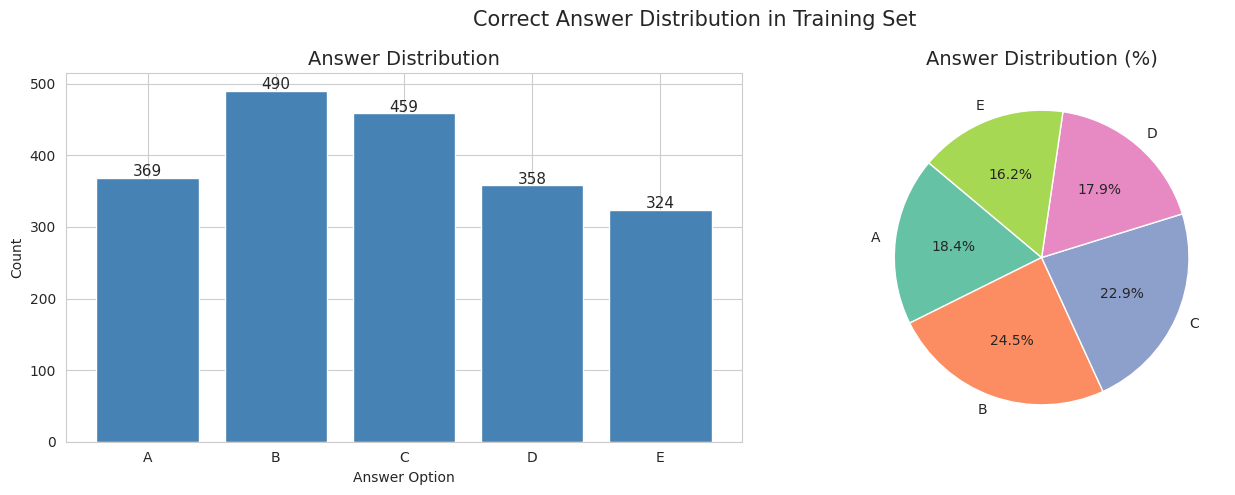


Most frequent answer : B → 490
Least frequent answer: E → 324


In [132]:
answer_counts = train['answer'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
axes[0].bar(answer_counts.index, answer_counts.values, color='steelblue', edgecolor='white')
axes[0].set_title("Answer Distribution", fontsize=14)
axes[0].set_xlabel("Answer Option")
axes[0].set_ylabel("Count")
for i, v in enumerate(answer_counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontsize=11)

# Pie chart
axes[1].pie(answer_counts.values, labels=answer_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette("Set2", 5), startangle=140)
axes[1].set_title("Answer Distribution (%)", fontsize=14)

plt.suptitle("Correct Answer Distribution in Training Set", fontsize=15)
plt.tight_layout()
plt.show()

print("\nMost frequent answer :", answer_counts.idxmax(), "→", answer_counts.max())
print("Least frequent answer:", answer_counts.idxmin(), "→", answer_counts.min())


##  Visualization 2 — Prompt Word Count vs Correct Answer



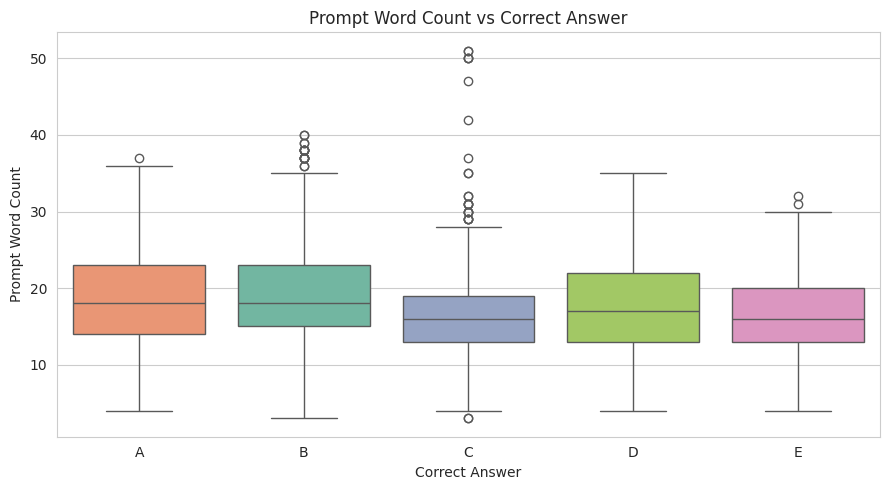

Mean prompt length per answer:
answer
A    19.06
B    19.56
C    17.10
D    17.86
E    16.76
Name: prompt_word_count, dtype: float64


In [133]:
plt.figure(figsize=(9, 5))
sns.boxplot(x='answer', y='prompt_word_count', data=train,
            order=sorted(train['answer'].unique()), palette='Set2',
            hue='answer', legend=False)
plt.title("Prompt Word Count vs Correct Answer")
plt.xlabel("Correct Answer")
plt.ylabel("Prompt Word Count")
plt.tight_layout()
plt.show()

print("Mean prompt length per answer:")
print(train.groupby('answer')['prompt_word_count'].mean().round(2))


# **Baseline Model — TF-IDF + Cosine Similarity**

##  A simple, untrained baseline using TF-IDF vectorization and cosine similarity to rank options by their word-overlap with the prompt. No model learning is involved — this establishes a reference point to compare our trained models against, which are actually learning meaningful patterns, or just matching keywords. 


## TF-IDF Vectorizer 

In [134]:
vectorizer_base = TfidfVectorizer(stop_words='english')
all_texts = []
for _, row in train.iterrows():
    all_texts.append(str(row['prompt']))
    for opt in OPTION_COLS:
        all_texts.append(str(row[opt]))
vectorizer_base.fit(all_texts)
print("Baseline TF-IDF vocabulary size:", len(vectorizer_base.vocabulary_))

Baseline TF-IDF vocabulary size: 2762


## Define MAP@3 Metric and Similarity Ranking Function 

In [135]:
def map_at_3_baseline(ground_truth, predictions):
    score = 0.0
    for k, pred in enumerate(predictions[:3], start=1):
        if pred == ground_truth:
            score = 1.0 / k
            break
    return score


def rank_options_by_similarity(row, vectorizer):
    prompt_vec = vectorizer.transform([str(row['prompt'])])
    sims = {}
    for opt in OPTION_COLS:
        opt_vec = vectorizer.transform([str(row[opt])])
        sims[opt] = cosine_similarity(prompt_vec, opt_vec)[0][0]
    ranked = sorted(sims, key=sims.get, reverse=True)
    return ranked

## Evaluate Baseline Performance (Train MAP@3) 

In [136]:
baseline_scores = []
for _, row in train.iterrows():
    ranked = rank_options_by_similarity(row, vectorizer_base)
    baseline_scores.append(map_at_3_baseline(row['answer'], ranked))

baseline_map3 = np.mean(baseline_scores)
print(f"Baseline (TF-IDF + Cosine Similarity) Train MAP@3: {baseline_map3:.4f}")

Baseline (TF-IDF + Cosine Similarity) Train MAP@3: 0.3119


## Generate Baseline Submission File

In [137]:
baseline_test_preds = []
for _, row in test.iterrows():
    ranked = rank_options_by_similarity(row, vectorizer_base)
    baseline_test_preds.append(' '.join(ranked[:3]))

baseline_submission = pd.DataFrame({
    'ID': test['id'],
    'Prediction': baseline_test_preds
})
baseline_submission.to_csv('submission_baseline.csv', index=False)   
print("Baseline submission saved as submission_baseline.csv")
baseline_submission.head()

Baseline submission saved as submission_baseline.csv


,ID,Prediction
0,1,A B C
1,2,A B C
2,3,A D C
3,4,A E C
4,5,A C E


# **Model 1 — TF-IDF + Logistic Regression**

---
##  Our first main model — a classical ML approach (the "additional model of choice" category), unlike the untrained baseline. My Approch is Combine prompt + all 5 options into one text → convert to TF-IDF vectors (unigrams to trigrams) → train a Logistic Regression classifier to predict the correct option → rank predicted probabilities to get top-3 answers for MAP@3. It Shows how far a simple, fast, interpretable classical ML model can go using strong TF-IDF features, without any neural network involved.



## W&B Setup 

In [138]:
import os
os.environ["WANDB_SILENT"] = "true"

from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
os.environ["WANDB_API_KEY"] = user_secrets.get_secret("WANDB_API_KEY")

wandb.init(
    project="smart-mcq-solver",
    name="model1-tfidf-logistic",
    config={
        "model"        : "LogisticRegression",
        "max_features" : 100000,
        "ngram_range"  : "(1,3)",
        "C"            : 10.0,
        "max_iter"     : 2000,
        "sublinear_tf" : True
    }
)
print("W&B ready.")

W&B ready.


## Combine Prompt + Options Into Single Text

In [139]:
def combine_text(row):
    parts = [str(row['prompt'])] + [str(row[c]) for c in OPTION_COLS]
    return ' '.join(parts)

train['combined'] = train.apply(combine_text, axis=1)
test['combined']  = test.apply(combine_text, axis=1)
print("Text combined.")

Text combined.


## TF-IDF Vectorization

In [140]:
vectorizer = TfidfVectorizer(
    max_features=100000,
    ngram_range=(1, 3),
    stop_words='english',
    sublinear_tf=True,
    min_df=1,
    analyzer='word'
)

X_train = vectorizer.fit_transform(train['combined'])
X_test  = vectorizer.transform(test['combined'])

le = LabelEncoder()
y_train = le.fit_transform(train['answer'])

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("Classes:", le.classes_)

X_train: (2000, 25642)
X_test : (500, 25642)
Classes: ['A' 'B' 'C' 'D' 'E']


## Train Logistic Regression

In [141]:
clf = LogisticRegression(
    max_iter=2000,
    C=10.0,
    solver='lbfgs',
    n_jobs=-1
)

clf.fit(X_train, y_train)
print("Model trained.")

Model trained.


## Evaluate MAP@3

In [142]:
def map_at_3_logreg(ground_truth, predictions):
    score = 0.0
    for k, pred in enumerate(predictions[:3], start=1):
        if pred == ground_truth:
            score = 1.0 / k
            break
    return score

probs      = clf.predict_proba(X_train)
top3_idx   = np.argsort(probs, axis=1)[:, ::-1][:, :3]
top3_preds = [[le.classes_[i] for i in row] for row in top3_idx]

scores     = [map_at_3_logreg(true, pred) for true, pred in zip(train['answer'], top3_preds)]
train_map3_logreg = np.mean(scores)
print(f"Train MAP@3: {train_map3_logreg:.4f}")

wandb.log({"train_map3": train_map3_logreg})

Train MAP@3: 1.0000


## Generate Submission

In [143]:
probs_test = clf.predict_proba(X_test)
top3_idx   = np.argsort(probs_test, axis=1)[:, ::-1][:, :3]
test_preds = [' '.join([le.classes_[i] for i in row]) for row in top3_idx]

submission = pd.DataFrame({
    'ID'         : test['id'],
    'Prediction' : test_preds
})
submission.to_csv('submission.csv', index=False)  
print("Submission created as submission.csv")
print(submission.head(10))

wandb.finish()

Submission created as submission.csv
   ID Prediction
0   1      A B E
1   2      B C A
2   3      B C D
3   4      E C B
4   5      C D E
5   6      D C A
6   7      E C B
7   8      B C D
8   9      C B D
9  10      B C D


train_map3,▁
train_map3,1
